/Users/shengfang/anaconda3/lib/python3.11/site-packages/spectral/graphics/spypylab.py:796: UserWarning: Failed to create RectangleSelector object. Interactive pixel class labeling will be unavailable.
  warnings.warn(msg)


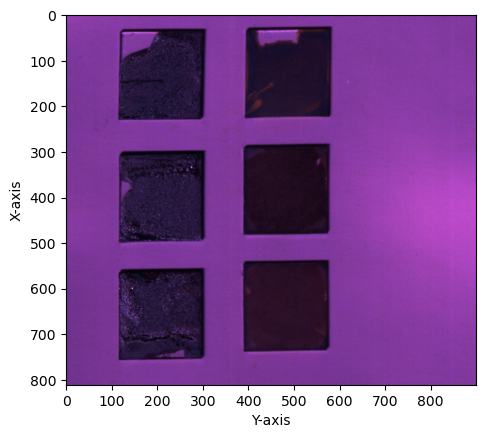

In [67]:
from scipy import ndimage
import matplotlib.pyplot as plt
from matplotlib.pyplot import *
from spectral import *
# Paths to your HDR and BIL files
hdr_file = '/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_BO_20251002/third_round_BO_20251002.bil.hdr'
bil_file = '/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_BO_20251002/third_round_BO_20251002.bil'
# Open the ENVI dataset and load it into a hypercube
hypercube = envi.open(hdr_file, bil_file).load()

# Display the image
imshow(hypercube, bands = (154, 78, 27))  # 'gray' colormap for single-band image

# Labeling the axes
plt.xlabel('Y-axis')
plt.ylabel('X-axis')

plt.show()

/var/folders/fp/lm995cv51pb66b54k2s3ts5w0000gn/T/ipykernel_9086/4187645066.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  spectra = pd.read_csv(f'/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_BO_20251002/pixel_reflectance_{film_idx}.csv', header=None)
/var/folders/fp/lm995cv51pb66b54k2s3ts5w0000gn/T/ipykernel_9086/4187645066.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = mpl.cm.get_cmap('RdPu')


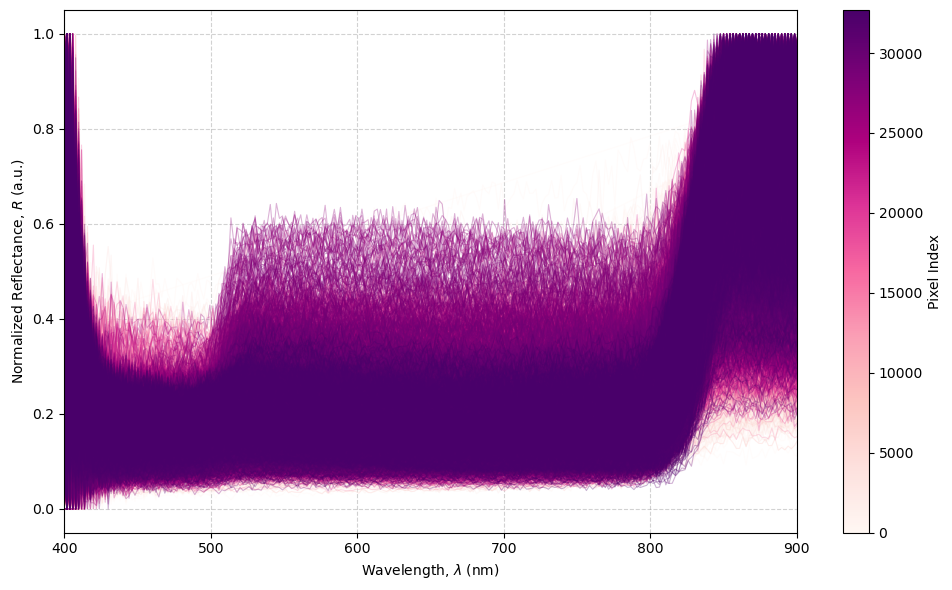

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Load the data
film_idx = 0
spectra = pd.read_csv(f'/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_BO_20251002/pixel_reflectance_{film_idx}.csv', header=None)
Y = spectra.to_numpy()
Y = Y[1:, :]  # Remove first row if it contains wavelength data

# Load wavelength
wavelength = pd.read_csv('/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2023–2026 First Solar/03 Inorganic_Discovery/03_Data/bandgap bowing/HS camera/wavelength.txt', sep='\t', header=None)
wavelength = wavelength[0].values

# Ensure data is numeric
Y = pd.DataFrame(Y).apply(pd.to_numeric, errors='coerce').fillna(0).values

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
colormap = mpl.cm.get_cmap('RdPu')

# Plot each pixel spectrum with a different color
n_pixels = Y.shape[1]
for i in range(n_pixels):
    # Normalize color index to [0, 1] range
    color_idx = i / (n_pixels - 1) if n_pixels > 1 else 0
    rgba = colormap(color_idx)
    
    # Normalize each spectrum for visualization (optional)
    spectrum = Y[:, i]
    if np.max(spectrum) > 0:  # Avoid division by zero
        normalized_spectrum = spectrum / np.max(spectrum)
    else:
        normalized_spectrum = spectrum
    
    ax.plot(wavelength, normalized_spectrum, c=rgba, linestyle='-', alpha=0.3, linewidth=0.8)

# Styling
ax.grid(which='minor', color='gray', linestyle='--', alpha=0.35)
ax.grid(which='major', color='gray', linestyle='--', alpha=0.35)
ax.set_xlabel(r'Wavelength, $\lambda$ (nm)')
ax.set_ylabel(r'Normalized Reflectance, $R$ (a.u.)')
ax.set_xlim(400, 900)

# Add colorbar
sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=n_pixels-1), cmap=colormap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Pixel Index')

# plt.title(f'Film 0 - All Pixel Spectra (n={n_pixels})')
plt.tight_layout()
# plt.savefig('/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/film_0_all_spectra.png', dpi=300)
plt.show()

/var/folders/fp/lm995cv51pb66b54k2s3ts5w0000gn/T/ipykernel_9086/3756766353.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  spectra = pd.read_csv(f'/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_BO_20251002/pixel_reflectance_{film_idx}.csv', header=None)


Original data shape: (300, 32692)
Number of wavelengths: 300
Number of pixels: 32692
  Extreme outliers found: 2 pixels
  Extreme outlier indices: [0 1]
    Pixel 0: intensity = 44850.00 (z-score = 37.96)
    Pixel 1: intensity = 208215.90 (z-score = 176.76)

Final conservative outlier removal:
  Total outliers to remove: 2 pixels
  Percentage to remove: 0.01%
  Final outlier indices: [0 1]


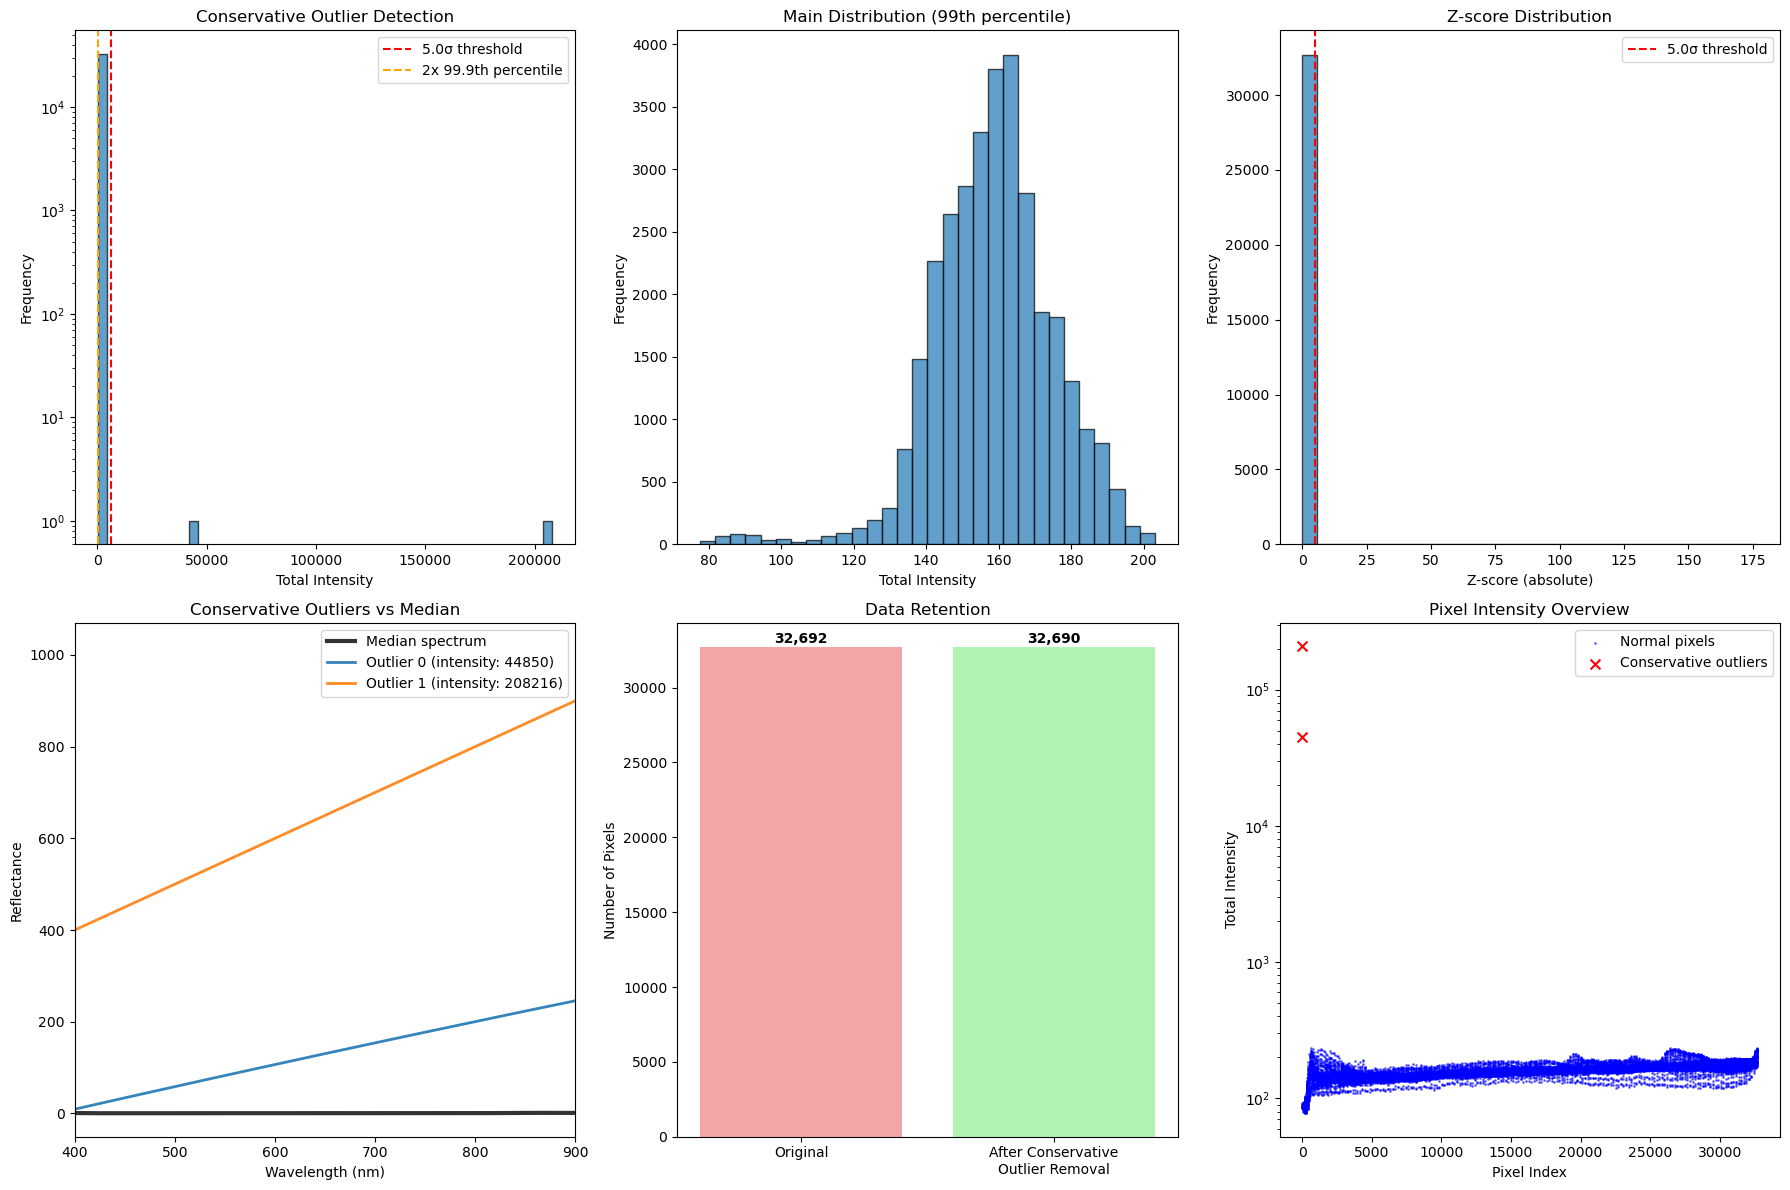


After conservative outlier removal:
  Original pixels: 32,692
  Cleaned pixels: 32,690
  Removed pixels: 2
  Percentage removed: 0.006%


In [69]:
# remove extreme outliers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load the data
spectra = pd.read_csv(f'/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_BO_20251002/pixel_reflectance_{film_idx}.csv', header=None)
Y = spectra.to_numpy()
Y = Y[1:, :]  # Remove first row if it contains wavelength data
# Load wavelength
wavelength = pd.read_csv('/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2023–2026 First Solar/03 Inorganic_Discovery/03_Data/bandgap bowing/HS camera/wavelength.txt', sep='\t', header=None)
wavelength = wavelength[0].values

Y = pd.DataFrame(Y).apply(pd.to_numeric, errors='coerce').fillna(0).values

print(f"Original data shape: {Y.shape}")
print(f"Number of wavelengths: {len(wavelength)}")
print(f"Number of pixels: {Y.shape[1]}")

# Transpose data so each row is a pixel spectrum
Y_transposed = Y.T  # Shape: (n_pixels, n_wavelengths)

# Method 1: Only remove pixels with extremely high total intensity (clear experimental errors)
total_intensities = np.sum(Y_transposed, axis=1)
mean_intensity = np.mean(total_intensities)
std_intensity = np.std(total_intensities)

# Use a much higher threshold - only remove pixels that are truly extreme (>5 standard deviations)
extreme_threshold = 5.0  # Much more conservative than 3.0
z_scores = np.abs(stats.zscore(total_intensities))
extreme_outliers = z_scores > extreme_threshold
print(f"  Extreme outliers found: {np.sum(extreme_outliers)} pixels")

if np.sum(extreme_outliers) > 0:
    extreme_indices = np.where(extreme_outliers)[0]
    print(f"  Extreme outlier indices: {extreme_indices}")
    for idx in extreme_indices:
        print(f"    Pixel {idx}: intensity = {total_intensities[idx]:.2f} (z-score = {z_scores[idx]:.2f})")

# Additional check: Look for pixels with impossible or clearly erroneous values
max_reasonable_intensity = np.percentile(total_intensities, 99.9)  # 99.9th percentile
unreasonable_outliers = total_intensities > max_reasonable_intensity * 2  # More than 2x the 99.9th percentile

# Combine extreme outlier criteria (use OR to catch any clearly bad pixels)
conservative_outliers = extreme_outliers | unreasonable_outliers

print(f"\nFinal conservative outlier removal:")
print(f"  Total outliers to remove: {np.sum(conservative_outliers)} pixels")
print(f"  Percentage to remove: {np.sum(conservative_outliers)/Y.shape[1]*100:.2f}%")

if np.sum(conservative_outliers) > 0:
    final_outlier_indices = np.where(conservative_outliers)[0]
    print(f"  Final outlier indices: {final_outlier_indices}")

# Visualize the conservative outlier detection
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Total intensity distribution with conservative threshold
axes[0, 0].hist(total_intensities, bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].axvline(mean_intensity + extreme_threshold*std_intensity, color='red', linestyle='--', 
                  label=f'{extreme_threshold}σ threshold')
axes[0, 0].axvline(max_reasonable_intensity * 2, color='orange', linestyle='--', 
                  label='2x 99.9th percentile')
axes[0, 0].set_xlabel('Total Intensity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Conservative Outlier Detection')
axes[0, 0].legend()
axes[0, 0].set_yscale('log')  # Log scale to see the outliers better

# Plot 2: Zoomed view of the main distribution
main_data = total_intensities[total_intensities < np.percentile(total_intensities, 99)]
axes[0, 1].hist(main_data, bins=30, alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Total Intensity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Main Distribution (99th percentile)')

# Plot 3: Z-scores
axes[0, 2].hist(z_scores, bins=30, alpha=0.7, edgecolor='black')
axes[0, 2].axvline(extreme_threshold, color='red', linestyle='--', 
                  label=f'{extreme_threshold}σ threshold')
axes[0, 2].set_xlabel('Z-score (absolute)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Z-score Distribution')
axes[0, 2].legend()

# Plot 4: Conservative outlier spectra vs median
median_spectrum = np.median(Y_transposed, axis=0)
axes[1, 0].plot(wavelength, median_spectrum, 'k-', linewidth=3, label='Median spectrum', alpha=0.8)

if np.sum(conservative_outliers) > 0:
    conservative_outlier_indices = np.where(conservative_outliers)[0]
    for i, idx in enumerate(conservative_outlier_indices):
        axes[1, 0].plot(wavelength, Y_transposed[idx], alpha=0.9, linewidth=2,
                       label=f'Outlier {idx} (intensity: {total_intensities[idx]:.0f})')
else:
    axes[1, 0].text(0.5, 0.5, 'No outliers found', ha='center', va='center', 
                   transform=axes[1, 0].transAxes, fontsize=14)

axes[1, 0].set_xlabel('Wavelength (nm)')
axes[1, 0].set_ylabel('Reflectance')
axes[1, 0].set_title('Conservative Outliers vs Median')
axes[1, 0].legend()
axes[1, 0].set_xlim(400, 900)

# Plot 5: Before vs after comparison
axes[1, 1].bar(['Original', 'After Conservative\nOutlier Removal'], 
              [Y.shape[1], Y.shape[1] - np.sum(conservative_outliers)], 
              color=['lightcoral', 'lightgreen'], alpha=0.7)
axes[1, 1].set_ylabel('Number of Pixels')
axes[1, 1].set_title('Data Retention')
for i, v in enumerate([Y.shape[1], Y.shape[1] - np.sum(conservative_outliers)]):
    axes[1, 1].text(i, v + 100, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Plot 6: Intensity scatter plot with outliers marked
axes[1, 2].scatter(range(len(total_intensities)), total_intensities, 
                  alpha=0.5, s=1, color='blue', label='Normal pixels')
if np.sum(conservative_outliers) > 0:
    outlier_indices = np.where(conservative_outliers)[0]
    axes[1, 2].scatter(outlier_indices, total_intensities[outlier_indices], 
                      color='red', s=50, marker='x', label='Conservative outliers')
axes[1, 2].set_xlabel('Pixel Index')
axes[1, 2].set_ylabel('Total Intensity')
axes[1, 2].set_title('Pixel Intensity Overview')
axes[1, 2].legend()
axes[1, 2].set_yscale('log')

plt.tight_layout()
plt.show()

# Remove conservative outliers
Y_conservatively_cleaned = Y[:, ~conservative_outliers]
Y_transposed_conservatively_cleaned = Y_conservatively_cleaned.T

print(f"\nAfter conservative outlier removal:")
print(f"  Original pixels: {Y.shape[1]:,}")
print(f"  Cleaned pixels: {Y_conservatively_cleaned.shape[1]:,}")
print(f"  Removed pixels: {np.sum(conservative_outliers)}")
print(f"  Percentage removed: {np.sum(conservative_outliers)/Y.shape[1]*100:.3f}%")

# Store conservatively cleaned data
conservative_cleaned_data = {
    'Y_cleaned': Y_conservatively_cleaned,
    'Y_transposed_cleaned': Y_transposed_conservatively_cleaned,
    'outlier_mask': conservative_outliers,
    'outlier_indices': np.where(conservative_outliers)[0] if np.sum(conservative_outliers) > 0 else [],
    'wavelength': wavelength,
}

Explained variance ratios: [0.3647569  0.23463552 0.137732   0.07901754 0.0461367  0.02365147
 0.01729119 0.01483094 0.01284928 0.01038084 0.0070388  0.00540054]
cumulative_variance_ratios: 0.9537217278050133
Singular values: [368.57054645 295.60770305 226.48335945 171.54600583 131.08172421
  93.85296133  80.24747433  74.31957575  69.17643629  62.17777363
  51.19980275  44.84742926]
PCA components shape: (12, 300)


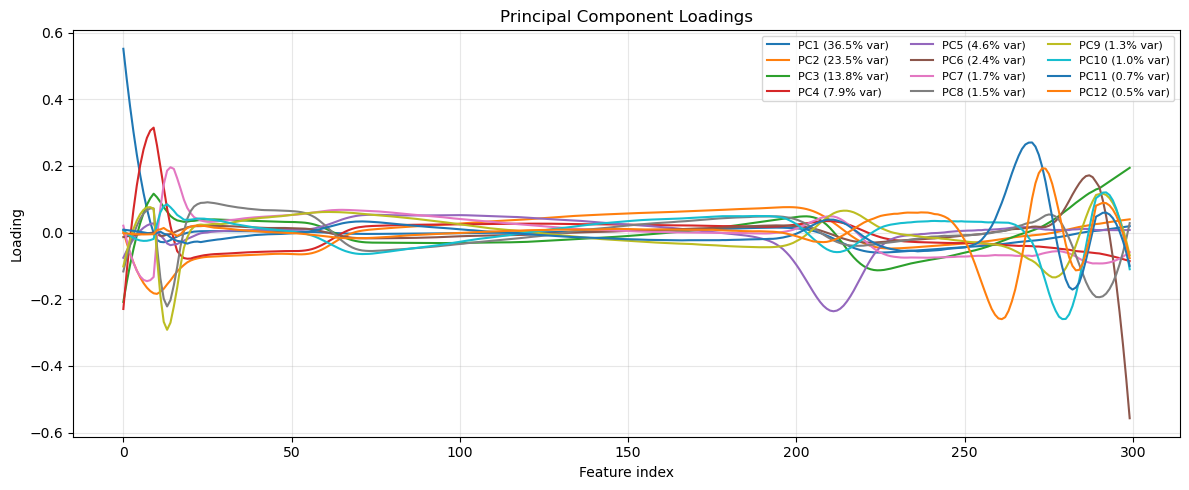

In [70]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter

# Y_conservatively_cleaned: columns are spectra
Y = np.asarray(Y_conservatively_cleaned)
Y = Y.T  

# Standard Normal Variate (SNV): center & scale each spectrum individually
Y = (Y - Y.mean(axis=1, keepdims=True)) / Y.std(axis=1, ddof=1, keepdims=True)

# Feature scaling for PCA
Y_smooth = savgol_filter(Y, window_length=20, polyorder=2, axis=1)
scaler = StandardScaler(with_mean=True, with_std=False)
Y_scaled = scaler.fit_transform(Y_smooth)   # centers each wavelength across spectra

# 3) PCA
for i in range(1, Y.shape[1]+1):
    pca = PCA(n_components=i, svd_solver='randomized', random_state=0)  
    Y_pca = pca.fit_transform(Y_scaled)
    cumulative_variance_ratios = np.cumsum(pca.explained_variance_ratio_)
    if cumulative_variance_ratios[-1] >= 0.95:
        break
    else:
        i = i + 1

pca = PCA(n_components=i, svd_solver='randomized', random_state=0)
Y_pca = pca.fit_transform(Y_scaled)
cumulative_variance_ratios = np.cumsum(pca.explained_variance_ratio_)

print("Explained variance ratios:", pca.explained_variance_ratio_)
print("cumulative_variance_ratios:", cumulative_variance_ratios[-1])
print("Singular values:", pca.singular_values_)
# pca.components_: shape (3, 300), loadings of the 3 PCs over wavelengths
print("PCA components shape:", pca.components_.shape)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
for i in range(pca.components_.shape[0]):
    plt.plot(pca.components_[i], label=f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}% var)')
plt.title('Principal Component Loadings')
plt.xlabel('Wavelength' if 'wavelengths' in globals() else 'Feature index')
plt.ylabel('Loading')
plt.legend(ncol=3, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



ε-silhouette pick: k=2 (ε=0.98, best_sil=0.247)
[auto] chosen k = 2 by ε-silhouette
Cosine(mean0, mean1)=0.994302 | rel_L2=0.1118 | sil*=0.247
Clusters are practically indistinguishable → merging to one cluster (k=1).
Cluster sizes: {0: 32690}


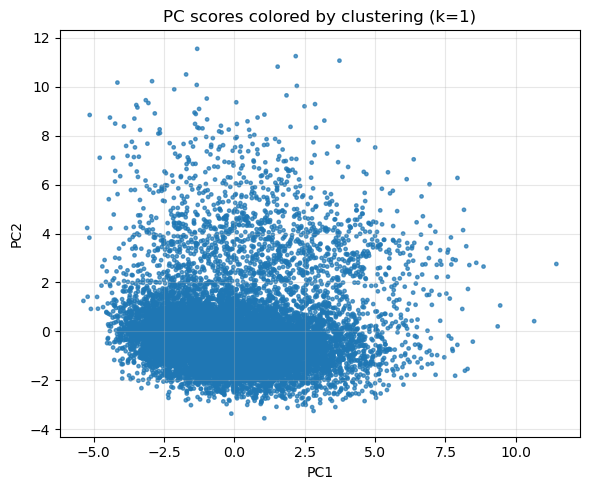

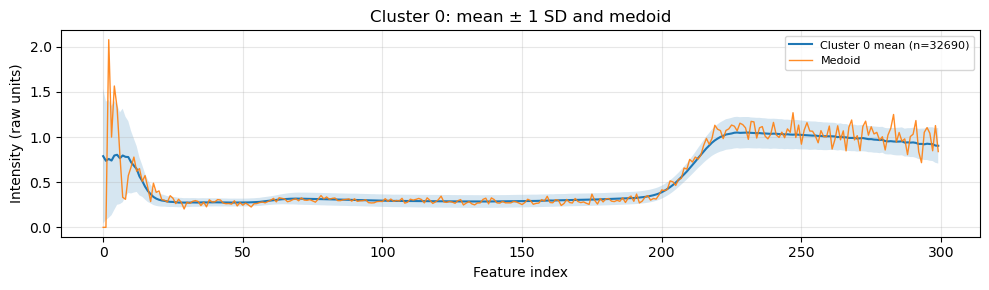

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    pairwise_distances_argmin_min
)
from numpy.linalg import norm

# ---------------------------------------------------------------------
Z = Y_pca                    # (n_samples, n_pcs)
n_samples = Z.shape[0]
rng = np.random.default_rng(0)

# Helper metrics
def cos_sim(a, b):
    return float(np.dot(a, b) / (norm(a) * norm(b) + 1e-12))

# Scan k >= 2 with MiniBatchKMeans + metrics ===
k_range = range(2, 15)
metrics = []   # (k, sil, ch, db, inertia, model)

for k in k_range:
    km = MiniBatchKMeans(n_clusters=k, batch_size=4096, n_init=50, random_state=0)
    labels_k = km.fit_predict(Z)
    sil = silhouette_score(Z, labels_k, sample_size=min(10000, n_samples), random_state=0)
    ch  = calinski_harabasz_score(Z, labels_k)
    db  = davies_bouldin_score(Z, labels_k)
    metrics.append((k, sil, ch, db, km.inertia_, km))

ks, sils, chs, dbs, inerts, kms = map(np.array, zip(*metrics))

# Conservative “within-ε of best” silhouette (avoid over-splitting) ===
eps = 0.98
sil_star = sils.max()
k_sil_eps = int(ks[sils >= eps * sil_star].min())
print(f"ε-silhouette pick: k={k_sil_eps} (ε={eps}, best_sil={sil_star:.3f})")

# Start from silhouette-based choice
k_final = k_sil_eps
kmeans = kms[sils >= eps * sil_star][0]
labels = kmeans.predict(Z)
print(f"[auto] chosen k = {k_final} by ε-silhouette")

# Post-hoc merge for k=2 if clusters are nearly identical ===
if k_final == 2:
    # Compare cluster means in RAW spectral units
    Y_raw = np.asarray(Y_conservatively_cleaned).T
    ids = np.unique(labels)
    mu0 = Y_raw[labels == ids[0]].mean(axis=0)
    mu1 = Y_raw[labels == ids[1]].mean(axis=0)
    cos = cos_sim(mu0, mu1)
    rel_l2 = norm(mu0 - mu1) / (norm(mu0) + 1e-12)

    print(f"Cosine(mean0, mean1)={cos:.6f} | rel_L2={rel_l2:.4f} | sil*={sil_star:.3f}")

    # Merge if weak separation on multiple criteria (tune thresholds if needed)
    if cos >= 0.992 and rel_l2 <= 0.15 and sil_star <= 0.3:
        print("Clusters are practically indistinguishable → merging to one cluster (k=1).")
        k_final = 1
        labels = np.zeros(n_samples, dtype=int)
        kmeans = None

# Sizes 
unique, counts = np.unique(labels, return_counts=True)
print("Cluster sizes:", dict(zip(unique, counts)))

# Scatter in PC space
sub = rng.choice(n_samples, size=min(15000, n_samples), replace=False)
plt.figure(figsize=(6,5))
plt.scatter(Z[sub, 0], Z[sub, 1], c=labels[sub], s=6, alpha=0.7, cmap='tab10')
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(f"PC scores colored by clustering (k={k_final})")
plt.grid(True, alpha=0.3) 
plt.tight_layout()
plt.savefig(f'/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_BO_20251002/PC_scatter_colored_by_clustering_{film_idx}.png', dpi=300)
plt.show()

# Mean ± SD & medoids (works for k=1 or >1)
Y_raw = np.asarray(Y_conservatively_cleaned).T
x = np.arange(Y_raw.shape[1])

if k_final == 1:
    from sklearn.metrics import pairwise_distances_argmin_min
    centroid = Z.mean(axis=0, keepdims=True)
    midx, _ = pairwise_distances_argmin_min(centroid, Z)
    medoid_idx = [int(midx[0])]
    cluster_ids = [0]
else:
    medoid_idx = []
    cluster_ids = sorted(np.unique(labels).tolist())
    for c in cluster_ids:
        idx = np.where(labels == c)[0]
        m_idx, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_[c:c+1], Z[idx])
        medoid_idx.append(int(idx[m_idx[0]]))

cluster_means = []; cluster_stds = []
for c in cluster_ids:
    idx = np.where(labels == c)[0]
    cluster_means.append(Y_raw[idx].mean(axis=0))
    cluster_stds.append(Y_raw[idx].std(axis=0, ddof=1))
cluster_means = np.vstack(cluster_means); cluster_stds = np.vstack(cluster_stds)

for j, c in enumerate(cluster_ids):
    plt.figure(figsize=(10,3))
    mu, sd = cluster_means[j], cluster_stds[j]
    plt.plot(x, mu, label=f"Cluster {c} mean (n={counts[j]})")
    plt.fill_between(x, mu - sd, mu + sd, alpha=0.18)
    plt.plot(x, Y_raw[medoid_idx[j]], lw=1, alpha=0.9, label="Medoid")
    plt.xlabel("Wavelength" if 'wavelengths' in globals() else "Feature index")
    plt.ylabel("Intensity (raw units)")
    plt.title(f"Cluster {c}: mean ± 1 SD and medoid")
    plt.grid(True, alpha=0.3); plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_BO_20251002/Cluster_{c}_mean_SD_medoid_{film_idx}.png', dpi=300)
    plt.show()


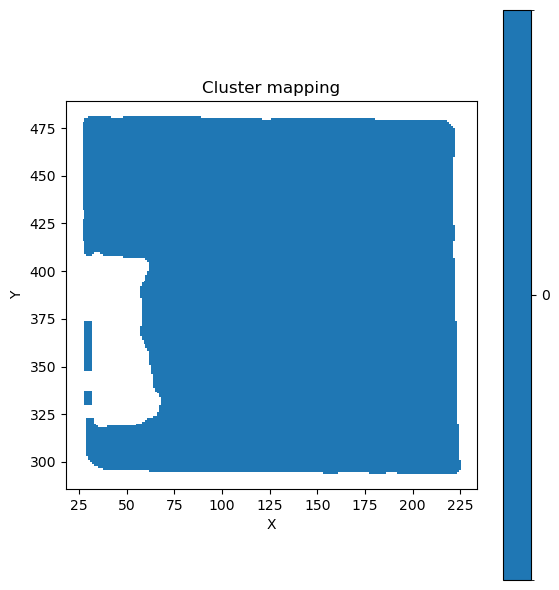

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

coords = pd.read_csv(f"/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_BO_20251002/pixel_coordinates_{film_idx}.csv")  # has X_coord, Y_coord
xs = coords["X_coord"].to_numpy().astype(int)
ys = coords["Y_coord"].to_numpy().astype(int)

u = np.unique(labels)
remap = {v:i for i,v in enumerate(u)}
labels_mapped = np.vectorize(remap.get)(labels)

# 2) Discrete colormap / ticks match original IDs
cmap = plt.get_cmap("tab10", len(u))
norm = BoundaryNorm(np.arange(-0.5, len(u)+0.5), len(u))

plt.figure(figsize=(6,6))
plt.scatter(xs, ys, c=labels_mapped, cmap=cmap, norm=norm,
            s=9, marker='s', linewidths=0)  # square markers; adjust s for density
cb = plt.colorbar(ticks=np.arange(len(u)))
cb.ax.set_yticklabels([str(v) for v in u])  # show your original cluster IDs
plt.gca().set_aspect('equal', 'box')
plt.title("Cluster mapping")
plt.xlabel("X"); plt.ylabel("Y")
plt.savefig(f'/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_BO_20251002/cluster_mapping_{film_idx}.png', dpi=300)
plt.tight_layout()
plt.show()